# Описание задачи "Разработка нефтегазовых месторождений"

Набор данных содержит 442 о различных нефтегазовых месторождениях.
Тренировочный набор - 309 строк.
Тестовый набор - 133 строк.

Каждое месторождение обладает 19 параметрами:
1. Field name - название месторождения
2. Reservoir unit - юнит месторождения
3. Country - страна расположения
4. Region - регион расположения
5. Basin name - название бассейна пород
6. Tectonic regime - тектонический режим
7. Latitude - широта
8. Longitude - долгота
9. Operator company - название компании
10. Onshore or oﬀshore - на суше или нет
11. Hydrocarbon type (main) - тип углеводорода
12. Reservoir status (current) - статус месторождения
13. Structural setting - структурные свойства
14. Depth (top reservoir ft TVD) - глубина
15. Reservoir period - литологический период
16. Lithology (main) - литология
17. Thickness (gross average ft) - общая толщина
18. Thickness (net pay average ft) - эффективная толщина
19. Porosity (matrix average.. - пористость
20. Permeability (air average mD) – проницаемость

**Что нужно сделать**:

Принять участие в соревновании на Kaggle:
Оно доступно по [ссылке](https://www.kaggle.com/competitions/classification-of-oil-and-gas/submissions#).

Разработать и оформить решение в ноутбуке:
* Исследование и анализ датасета.
* Предобработка данных.
* Feature Engineering (если необходимо).
* Подбор признаков, их анализ и оценка важности.
* Обучение нескольких моделей, их сравнение.
* Подбор гиперпараметров.
* Выбор лучшей модели и объяснение выбора.
* Предсказание на тестовых данных.


|**Критерии оценивания**||
|:---|:---|
|Анализ данных и их предобработка	|0-3 балла|
|Feature Engineering и отбор признаков	|0-2 балла|
|Выбор и обучение нескольких моделей	|0-3 балла|
|Подбор гиперпараметров и объяснение выбора лучшей модели	|0-2 балла|
|Результат на Kaggle	|0-1 балл|
|Качество оформления ноутбука (чистый код, комментарии, выводы)	|0-1 балл|
|**Итого**	|**12 баллов**|


# Импортирование библиотек

In [1]:
# базовые
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# для считывания датасетов с Kaggle
import opendatasets as od

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler



# Считывание данных

In [7]:
# Загрузим датасет на прямую с kaggle
# Для автомтическй загрузки надо положить файл kaggle.json в папку с ноутбуком
# kaggle.json скачивается в настройках Kaggle в разделе Legacy API Credentials
dataset_url = 'https://www.kaggle.com/competitions/classification-of-oil-and-gas/data'

od.download(dataset_url)

# Считываем тренировочные данные
train = pd.read_csv("./classification-of-oil-and-gas/train_oil.csv")
test = pd.read_csv("./classification-of-oil-and-gas/oil_test.csv")

# Сохраняем исходные данные
train_original = train.copy()
test_original = test.copy()

print(f"Train dataset shape: {train.shape}")
print(f"Test dataset shape: {test.shape}")

Skipping, found downloaded files in "./classification-of-oil-and-gas" (use force=True to force download)
Train dataset shape: (309, 20)
Test dataset shape: (133, 19)


In [8]:
# Посмотрим как выглядят данные
train.head(5)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


# Иследование и обработка данных (EDA)

## Общая информация

In [9]:
# процент дублей 
(len(train) - len( train.drop_duplicates() )) * 100 / len(train)

0.0

Дублирующих строк нет.

In [10]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    str    
 1   Reservoir unit                  309 non-null    str    
 2   Country                         282 non-null    str    
 3   Region                          271 non-null    str    
 4   Basin name                      271 non-null    str    
 5   Tectonic regime                 309 non-null    str    
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    str    
 9   Onshore/Offshore                309 non-null    str    
 10  Hydrocarbon type                309 non-null    str    
 11  Reservoir status                309 non-null    str    
 12  Structural setting              309 non-null   

In [11]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      133 non-null    str    
 1   Reservoir unit                  133 non-null    str    
 2   Country                         120 non-null    str    
 3   Region                          117 non-null    str    
 4   Basin name                      125 non-null    str    
 5   Tectonic regime                 133 non-null    str    
 6   Latitude                        120 non-null    float64
 7   Longitude                       117 non-null    float64
 8   Operator company                133 non-null    str    
 9   Hydrocarbon type                133 non-null    str    
 10  Reservoir status                133 non-null    str    
 11  Structural setting              133 non-null    str    
 12  Depth                           133 non-null   

## Обработка пропущенных значений

### Обзор

Есть пропущенные значения в тренировочных и тестовых данных. Визуализируем пропуски.

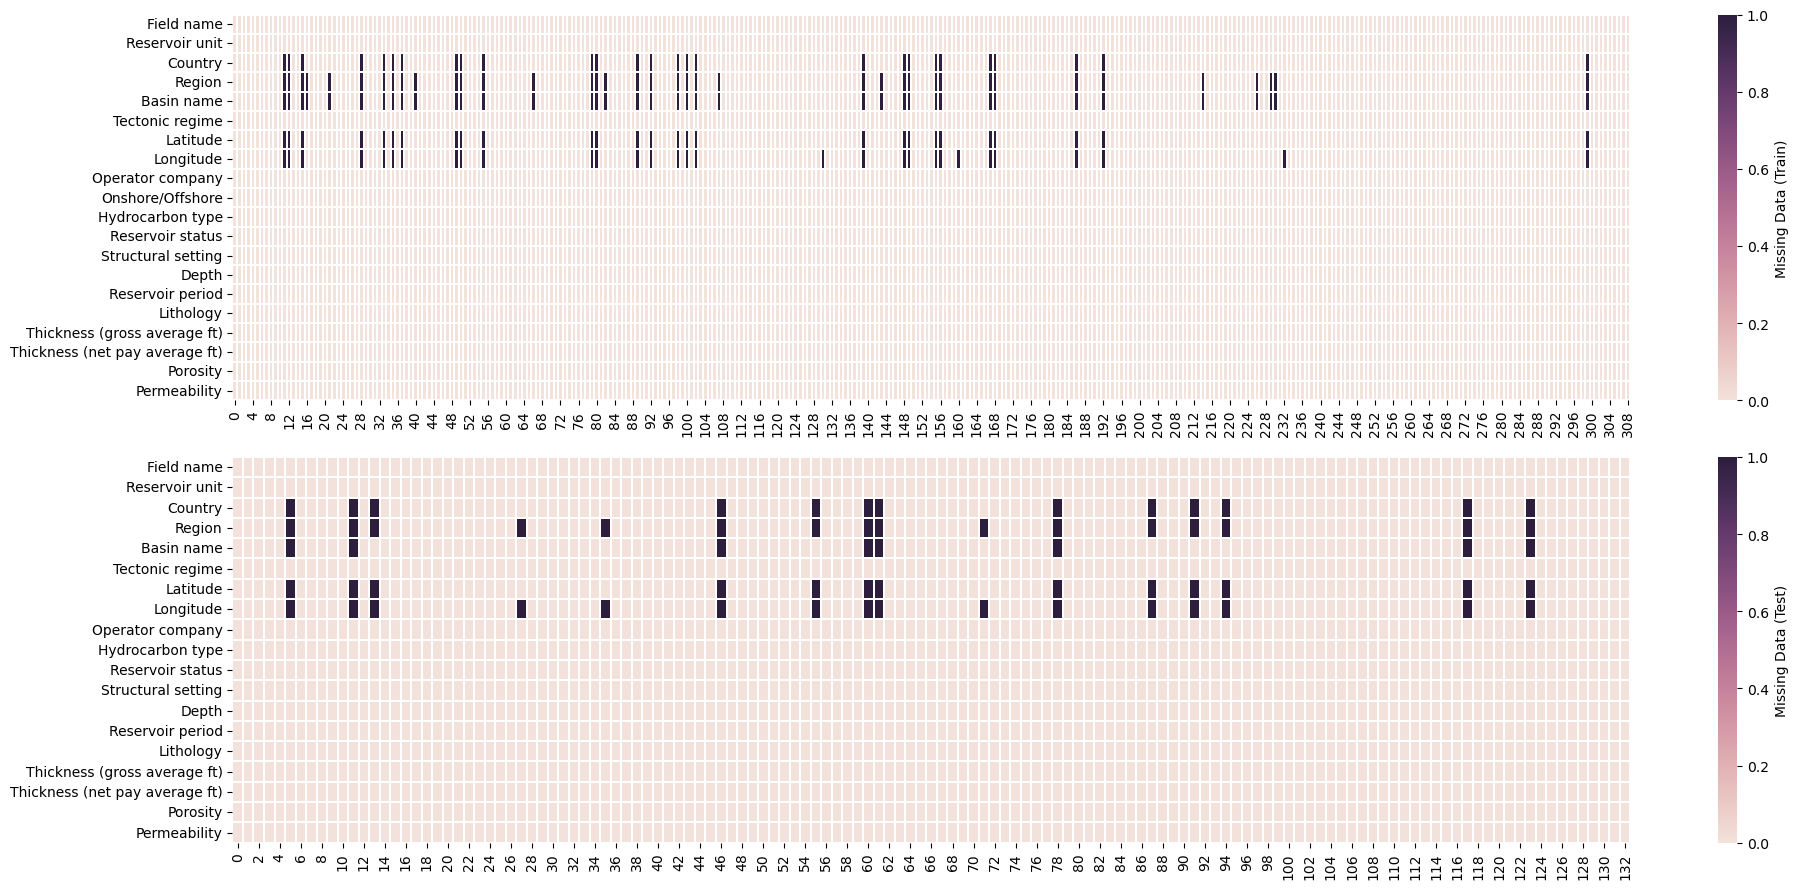

In [12]:
# для двух таблиц
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 9))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(train.isna().transpose(), cmap=cmap, ax=ax1,
            cbar_kws={'label': 'Missing Data (Train)'}, linewidths=0.003)

sns.heatmap(test.isna().transpose(), cmap=cmap, ax=ax2,
            cbar_kws={'label': 'Missing Data (Test)'}, linewidths=0.003)

plt.tight_layout()
plt.savefig("./classification-of-oil-and-gas/visualizing_missing_data_with_heatmap_Seaborn_Python.png", dpi=100)
plt.show()


In [14]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       27
Region        38
Basin name    38
Latitude      27
Longitude     30
dtype: int64

In [15]:
train.isna().sum().sum()

np.int64(160)

Поле Field name (название месторождения) у нас везде заполнено и если оно будет встречаться и там, и там, то по нему мы попробуем востановить пропущенные значения.

In [16]:
def fill_na(train_df, check_col, test_df):
    """Принимает train, поле (check_col), по которому надо свернуть, чтобы получить "средние", test.
    Возвращает: пересечние, где нет значений и где есть в train, заполненные ими train, test.
    """
    
    # Разделим данные на две таблицы, где есть пропуски и где все поля заполнены
    
    # .any(axis='columns') - перебирает все строки и помечает всю строку True, если есть хотя бы один NaN в любой колонке
    missed = train_df[train_df.isna().any(axis='columns')] 
    
    filled = train_df.dropna()
    
    # Получим список заполненных полей    
    filled_names = filled[check_col].unique()
    
    # Отберём те строки, в таблице с пропусками, которые есть без пропусков
    common_names = missed[missed[check_col].isin(filled_names)]
    
    # Выведем результат из общей таблицы, чтобы визуально оценить возможность заполнения пропусков
    visual_check = train_df[train_df[check_col].isin(common_names[check_col])].sort_values(check_col)

    # создадим таблицу справочник с модой и медианой по выбранному полю
    mapping = filled.groupby(check_col).agg({
        'Country': lambda x: x.mode().iat[0], # так как мода вычисляется, то для указания индекса используем iat 
        'Region': lambda x: x.mode().iat[0],
        'Basin name': lambda x: x.mode().iat[0],
        'Latitude': 'median',
        'Longitude':'median',
    })
        
    # Заполнение, сбрасываем индекс на название, заполняем из справочника, восстанавливаем индекс
    train_df_filled = train_df.set_index(check_col).fillna(mapping).reset_index()
    test_df_filled = test_df.set_index(check_col).fillna(mapping).reset_index()

    # Возвращаем таблицу для визуальной проверки, заполненные train и test
    return visual_check, train_df_filled, test_df_filled
        

### Fill Nan by *Field name*

In [17]:
visual_check, filled_train, filled_test = fill_na(train, 'Field name', test)

In [24]:
filled_train.isna().sum().sum()

np.int64(136)

In [19]:
visual_check

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,NaN,NaN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0
139,CAROLINE,SWAN HILLS (BEAVERHILL LAKE A),NaN,NaN,NaN,COMPRESSION,NaN,NaN,NUMEROUS,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,FORELAND,11500,DEVONIAN,DOLOMITE,300.0,60.0,10.0,100.0
196,CAROLINE,CARDIUM (E POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,51.9278,-114.5405,NUMEROUS,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,7975,CRETACEOUS,SANDSTONE,300.0,7.0,11.0,20.0
222,DURI,BEKASAP (KEDUA-PERTAMA SANDS),INDONESIA,FAR EAST,SUMATRA CENTRAL,INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/...,1.2956,101.2304,CALTEX PACIFIC INDONESIA,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/BACKARC,400,NEOGENE,SANDSTONE,280.0,150.0,34.0,1500.0
226,DURI,DURI (RINDU SAND),INDONESIA,NaN,NaN,INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/...,1.2956,101.2304,CALTEX PACIFIC INDONESIA,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/BACKARC,220,NEOGENE,SANDSTONE,120.0,52.0,32.0,1900.0
79,OROCUAL,SAN JUAN,NaN,NaN,NaN,COMPRESSION/EXTENSION/LINKED,NaN,NaN,PDVSA,ONSHORE,OIL,DECLINING PRODUCTION,THRUST/PASSIVE MARGIN,12550,CRETACEOUS-PALEOGENE,SANDSTONE,1000.0,650.0,6.0,5.0
144,OROCUAL,CARAPITA,VENEZUELA,LATIN AMERICA,EASTERN VENEZUELA,COMPRESSION/EXTENSION/LINKED,9.8667,-63.3333,PDVSA,ONSHORE,OIL,CONTINUING DEVELOPMENT,THRUST/FORELAND,10150,NEOGENE,SANDSTONE,300.0,160.0,13.0,35.0
49,YIBAL,KHUFF,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,PDO,ONSHORE,OIL,DECLINING PRODUCTION,SALT/FORELAND,9219,PERMIAN,DOLOMITE,670.0,250.0,15.0,5.0
173,YIBAL,SHUAIBA,OMAN,MIDDLE EAST,FAHUD SALT,COMPRESSION/EVAPORITE,22.1333,56.0000,PDO,ONSHORE,OIL,DECLINING PRODUCTION,SALT/FORELAND,4440,CRETACEOUS,CHALK,350.0,300.0,28.0,5.0


Видно, что можем смело заполнть пропуски по уже имеющимся данным.

In [20]:
# Проверим заполнение.

# как было
visual_check.head(2)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,NaN,NaN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0


In [21]:
# вывод как заполнилось
filled_train.loc[[218, 230]]

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0


In [25]:
# Применяем изменения
train, test = filled_train, filled_test

In [26]:
train.isna().sum().sum()

np.int64(136)

### Fill Nan by *Reservoir unit*

Теперь попробуем определить по полю *Reservoir unit*

In [27]:
visual_check, filled_train, filled_test = fill_na(train, 'Reservoir unit', test)

filled_train.isna().sum().sum()

np.int64(103)

In [28]:
visual_check

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BADR EL DIN-2,BAHARIYA,NaN,NaN,NaN,EXTENSION,NaN,NaN,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BADR EL DIN-1,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0
12,BRIDGER LAKE,DAKOTA SANDSTONE (LOWER MEMBER),NaN,NaN,NaN,COMPRESSION/EROSION,NaN,NaN,BTA OIL PRODUCERS,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,15460,CRETACEOUS,SANDSTONE,270.0,35.0,12.8,79.0
260,LUCKEY DITCH,DAKOTA SANDSTONE (LOWER MEMBER),USA,NORTH AMERICA,GREATER GREEN RIVER,COMPRESSION/EROSION,41.0204,-110.2755,WHITING OIL and GAS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,13250,CRETACEOUS,SANDSTONE,250.0,23.0,14.0,60.0
66,INDEFATIGABLE,LEMAN SANDSTONE,UK,NaN,NaN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.3932,2.5239,SHELL /PERENCO,OFFSHORE,GAS,NEARLY DEPLETED,SUB-SALT/INVERSION,7400,PERMIAN,SANDSTONE,200.0,197.0,15.0,30.0
125,CLIPPER,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.4682,1.7338,SHELL,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,7420,PERMIAN,SANDSTONE,715.0,580.0,11.0,0.5
137,VICTOR,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.3299,2.3626,CONOCOPHILLIPS,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,8175,PERMIAN,SANDSTONE,375.0,369.0,16.0,52.0
232,BARQUE,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.6204,NaN,SHELL,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,6900,PERMIAN,SANDSTONE,750.0,570.0,11.0,0.5
154,ELKHORN RANCH,MISSION CANYON (MADISON),USA,NORTH AMERICA,WILLISTON,COMPRESSION,47.2376,-103.5028,TENNECO /CENEX /SHELL,ONSHORE,OIL,DECLINING PRODUCTION,INTRACRATONIC,9125,CARBONIFEROUS,DOLOMITE,105.0,40.0,16.0,25.0
155,BEAVER LODGE,MISSION CANYON (MADISON),NaN,NaN,NaN,COMPRESSION,NaN,NaN,AMERADA HESS,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8350,CARBONIFEROUS,LIMESTONE,120.0,20.0,6.0,1.0


In [29]:
# Проверим заполнение.

# как было
indices = visual_check.tail(3).index
display(visual_check.tail(3))
# как заполнилось
filled_train.loc[indices]

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
99,KARACHAGANAK,UNNAMED,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,51.3158,53.2600,KARACHAGANAK INTEGRATED ORAGANIZATION,ONSHORE,GAS-CONDENSATE,REJUVENATING,SUB-SALT/FORELAND,11870,DEVONIAN-PERMIAN,LIMESTONE,6600.0,2600.0,10.0,8.0
185,PARENTIS,UNNAMED,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EROSION,44.3367,-1.0959,VERMILION,ONSHORE-OFFSHORE,OIL,NEARLY DEPLETED,FORELAND,6550,CRETACEOUS,DOLOMITE,1300.0,200.0,11.0,10.0
192,ORENBURG,UNNAMED,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
99,UNNAMED,KARACHAGANAK,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,51.31580,53.26000,KARACHAGANAK INTEGRATED ORAGANIZATION,ONSHORE,GAS-CONDENSATE,REJUVENATING,SUB-SALT/FORELAND,11870,DEVONIAN-PERMIAN,LIMESTONE,6600.0,2600.0,10.0,8.0
185,UNNAMED,PARENTIS,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EROSION,44.33670,-1.09590,VERMILION,ONSHORE-OFFSHORE,OIL,NEARLY DEPLETED,FORELAND,6550,CRETACEOUS,DOLOMITE,1300.0,200.0,11.0,10.0
192,UNNAMED,ORENBURG,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EVAPORITE,47.82625,26.08205,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


Есть поле *UNNAMED*, по которому восстановление не получится. Проверим есть ли у этого оператора другие месторождения.

In [30]:
train[train['Operator company'] == 'ORENBURGGAZPROM']

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
192,ORENBURG,UNNAMED,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


Заменим это поле на уникальное

In [31]:
mask = train['Reservoir unit'] == 'UNNAMED'
train.loc[mask, 'Reservoir unit'] = train.loc[mask, 'Field name'] + ' UNNAMED'


Сделаем ещё раз

In [32]:
visual_check, filled_train, filled_test = fill_na(train, 'Reservoir unit', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.head(2).index
display(visual_check.head(2))
# как заполнилось
filled_train.loc[indices]

np.int64(108)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BADR EL DIN-2,BAHARIYA,NaN,NaN,NaN,EXTENSION,NaN,NaN,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BADR EL DIN-1,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0


,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BAHARIYA,BADR EL DIN-2,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BAHARIYA,BADR EL DIN-1,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0


In [33]:
# Применяем изменения
train, test = filled_train, filled_test

train.isna().sum().sum()

np.int64(108)

### Fill Nan by *Basin name*

In [34]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       18
Region        26
Basin name    26
Latitude      18
Longitude     20
dtype: int64

In [37]:
train[train['Basin name'].notna() & train.isna().any(axis='columns')]

,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,GHADAMES,COMPRESSION/EROSION/EXTENSION,31.390,NaN,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
160,LOWER BAHARIYA,QARUN,EGYPT,AFRICA,GINDI,INVERSION/COMPRESSION/EXTENSION,29.783,NaN,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0


In [36]:
visual_check, filled_train, filled_test = fill_na(train, 'Basin name', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.head().index
display(visual_check.head())
# как заполнилось
filled_train.loc[indices]

np.int64(107)

,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,GHADAMES,COMPRESSION/EROSION/EXTENSION,31.39,NaN,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
194,KIRCHAOU,EL BORMA,TUNISIA /ALGERIA,AFRICA,GHADAMES,COMPRESSION/EXTENSION/EROSION/EVAPORITE,31.65,9.18,SITEP /SONATRACH,ONSHORE,OIL,DECLINING PRODUCTION,SUB-SALT,9022,TRIASSIC,SANDSTONE,353.0,190.0,17.0,500.0


,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,GHADAMES,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,COMPRESSION/EROSION/EXTENSION,31.39,9.18,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
194,GHADAMES,KIRCHAOU,EL BORMA,TUNISIA /ALGERIA,AFRICA,COMPRESSION/EXTENSION/EROSION/EVAPORITE,31.65,9.18,SITEP /SONATRACH,ONSHORE,OIL,DECLINING PRODUCTION,SUB-SALT,9022,TRIASSIC,SANDSTONE,353.0,190.0,17.0,500.0


In [27]:
# Применяем изменения
train, test = filled_train, filled_test

train.isna().sum().sum()

np.int64(107)

### Fill Nan by *Country*

Видно, что кое-где есть страна, но некоторые другие поля не заполнены.

In [28]:
train[train['Country'].notna() & train.isna().any(axis='columns')]

,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
16,NaN,BASSEIN (ZONE B),HEERA,INDIA,NaN,EXTENSION,18.1720,72.3130,ONGC,OFFSHORE,OIL,DECLINING PRODUCTION,PASSIVE MARGIN,4542,PALEOGENE,LIMESTONE,230.0,82.0,12.0,0.8
21,NaN,HUTTON,GIDGEALPA,AUSTRALIA,NaN,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
40,NaN,YATES,NORTH WARD-ESTES,USA,NaN,COMPRESSION,31.5777,-102.9918,WHITING OIL and GAS,ONSHORE,OIL,REJUVENATING,FORELAND,2600,PERMIAN,SILTSTONE,300.0,100.0,11.0,16.0
82,NaN,F2-F0,WEST TEBUK,RUSSIA,NaN,COMPRESSION/EVAPORITE,63.6375,54.9269,KOMINEFT,ONSHORE,OIL,DECLINING PRODUCTION,INVERSION/FORELAND,3493,DEVONIAN,LIMESTONE,980.0,200.0,12.0,200.0
107,NaN,LOWER GANCHAIGOU,GASIKULE,CHINA,NaN,COMPRESSION,38.1000,90.8700,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,10427,PALEOGENE,SANDSTONE,804.0,93.0,14.0,48.0
143,NaN,TEMBLOR,COALINGA,USA,NaN,COMPRESSION/STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,36.2674,-120.3659,CHEVRON AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,WRENCH/FOREARC,500,NEOGENE,SHALY SANDSTONE,700.0,190.0,34.0,850.0
160,GINDI,LOWER BAHARIYA,QARUN,EGYPT,AFRICA,INVERSION/COMPRESSION/EXTENSION,29.7830,NaN,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0
214,NaN,GRAYBURG,SOUTH COWDEN,USA,NaN,COMPRESSION,31.7490,-102.4430,NUMEROUS,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,4100,PERMIAN,DOLOMITE,400.0,90.0,8.8,15.0
229,NaN,POKUR (PK1-6),URENGOY,RUSSIA,NaN,COMPRESSION,66.0533,76.9497,TYUMENNEFTEGAZ,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,3514,CRETACEOUS,SANDSTONE,700.0,440.0,30.0,330.0


In [29]:
visual_check, filled_train, filled_test = fill_na(train, 'Country', test)

filled_train.isna().sum().sum()

np.int64(90)

In [30]:
indices = train[train['Country'].notna() & train.isna().any(axis='columns')].index

In [31]:
filled_train.loc[indices]

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
16,INDIA,CAMBAY,BASSEIN (ZONE B),HEERA,FAR EAST,EXTENSION,18.1720,72.3130,ONGC,OFFSHORE,OIL,DECLINING PRODUCTION,PASSIVE MARGIN,4542,PALEOGENE,LIMESTONE,230.0,82.0,12.0,0.8
21,AUSTRALIA,GIPPSLAND,HUTTON,GIDGEALPA,FAR EAST,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
40,USA,GULF OF MEXICO NORTHERN ONSHORE,YATES,NORTH WARD-ESTES,NORTH AMERICA,COMPRESSION,31.5777,-102.9918,WHITING OIL and GAS,ONSHORE,OIL,REJUVENATING,FORELAND,2600,PERMIAN,SILTSTONE,300.0,100.0,11.0,16.0
82,RUSSIA,SIBERIAN WESTERN,F2-F0,WEST TEBUK,FORMER SOVIET UNION,COMPRESSION/EVAPORITE,63.6375,54.9269,KOMINEFT,ONSHORE,OIL,DECLINING PRODUCTION,INVERSION/FORELAND,3493,DEVONIAN,LIMESTONE,980.0,200.0,12.0,200.0
107,CHINA,BOHAI,LOWER GANCHAIGOU,GASIKULE,FAR EAST,COMPRESSION,38.1000,90.8700,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,10427,PALEOGENE,SANDSTONE,804.0,93.0,14.0,48.0
143,USA,GULF OF MEXICO NORTHERN ONSHORE,TEMBLOR,COALINGA,NORTH AMERICA,COMPRESSION/STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,36.2674,-120.3659,CHEVRON AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,WRENCH/FOREARC,500,NEOGENE,SHALY SANDSTONE,700.0,190.0,34.0,850.0
160,EGYPT,GINDI,LOWER BAHARIYA,QARUN,AFRICA,INVERSION/COMPRESSION/EXTENSION,29.7830,31.3616,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0
214,USA,GULF OF MEXICO NORTHERN ONSHORE,GRAYBURG,SOUTH COWDEN,NORTH AMERICA,COMPRESSION,31.7490,-102.4430,NUMEROUS,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,4100,PERMIAN,DOLOMITE,400.0,90.0,8.8,15.0
229,RUSSIA,SIBERIAN WESTERN,POKUR (PK1-6),URENGOY,FORMER SOVIET UNION,COMPRESSION,66.0533,76.9497,TYUMENNEFTEGAZ,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,3514,CRETACEOUS,SANDSTONE,700.0,440.0,30.0,330.0


In [32]:
visual_check

,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
21,NaN,HUTTON,GIDGEALPA,AUSTRALIA,NaN,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
83,BONAPARTE,PLOVER,SUNRISE-TROUBADOUR,AUSTRALIA,FAR EAST,EXTENSION/TRANSTENSION,-9.5901,128.1538,WOODSIDE,OFFSHORE,GAS-CONDENSATE,UNDEVELOPED,WRENCH/PASSIVE MARGIN,6660,JURASSIC,SANDSTONE,591.0,279.0,14.0,28.0
110,GIPPSLAND,LATROBE (M1 UNIT),BARRACOUTA,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION/EROSION,-38.2786,147.7094,EXXONMOBIL /BHP BILLITON,OFFSHORE,OIL,TEMPORARILY SHUT-IN,INVERSION/RIFT,4360,PALEOGENE,SANDSTONE,98.0,49.0,27.0,5000.0
150,OTWAY,PRETTY HILL (SANDSTONE),KATNOOK,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION,-37.4556,140.7789,BORAL ENERGY RESOURCES LTD,ONSHORE,GAS,PLATEAU PRODUCTION,RIFT,9286,CRETACEOUS,SANDSTONE,221.0,62.0,14.5,8.6
209,GIPPSLAND,LATROBE (N-1 UNIT),SNAPPER,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION/EROSION,-38.2008,148.0136,EXXONMOBIL /BHP BILLITON,OFFSHORE,GAS-CONDENSATE,PLATEAU PRODUCTION,INVERSION/RIFT,3682,PALEOGENE,SANDSTONE,820.0,394.0,24.0,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,WILLISTON,SPEARFISH,WESTHOPE SOUTH,USA,NORTH AMERICA,COMPRESSION,48.8521,-101.0130,AMERADA HESS,ONSHORE,OIL,MATURE PRODUCTION,INTRACRATONIC,3275,TRIASSIC,SANDSTONE,43.0,15.5,14.0,13.5
303,PERMIAN,SAN ANDRES,EMMA,USA,NORTH AMERICA,COMPRESSION,32.1270,-102.6353,EXXONMOBIL,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4185,PERMIAN,DOLOMITE,350.0,40.0,8.0,3.0
306,UINTA,GREEN RIVER AND COLTON/WASATCH,ALTAMONT-BLUEBELL,USA,NORTH AMERICA,COMPRESSION,40.3000,-110.2100,NUMEROUS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,15250,PALEOGENE,SANDSTONE,8000.0,575.0,5.0,0.1
307,POWDER RIVER,MUDDY,BELL CREEK,USA,NORTH AMERICA,COMPRESSION,45.1039,-105.0967,SAMUEL GARY,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4300,CRETACEOUS,SANDSTONE,45.0,23.0,28.5,2250.0


In [33]:
train, test = filled_train, filled_test

### Fill Nan by *Operator company*

In [34]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       18
Basin name    18
Region        18
Latitude      18
Longitude     18
dtype: int64

In [35]:
indices_all = train[train.isna().any(axis='columns')].index
train[train.isna().any(axis='columns')]

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
15,NaN,NaN,SGIATH-PIPER,SCOTT,NaN,EXTENSION/EVAPORITE,NaN,NaN,NEXEN,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9940,JURASSIC,SANDSTONE,360.0,290.0,16.0,100.00
33,NaN,NaN,UPPER GANCHAIGOU-LOWER YOUSHAS,GASIKULE,NaN,COMPRESSION,NaN,NaN,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,4199,NEOGENE,SANDSTONE,3281.0,81.0,19.0,102.00
35,NaN,NaN,UNITS XIII-XVIII,UZEN,NaN,INVERSION/COMPRESSION/EXTENSION,NaN,NaN,MANGYSTAUMUNAIGAZ,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/RIFT,3440,JURASSIC,SANDSTONE,920.0,436.0,21.0,235.00
37,NaN,NaN,ULA,ULA,NaN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE,NaN,NaN,BP,OFFSHORE,OIL,MATURE PRODUCTION,SALT/INVERSION/RIFT,10744,JURASSIC,SANDSTONE,410.0,377.0,16.5,300.00
50,NaN,NaN,PACOOTA AND STAIRWAY,PALM VALLEY,NaN,COMPRESSION/EVAPORITE,NaN,NaN,MAGELLAN PETROLEUM,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,5656,ORDOVICIAN,SANDSTONE,2300.0,174.0,4.0,0.01
55,NaN,NaN,HUANGLONG,WUBAITI,NaN,COMPRESSION,NaN,NaN,PETROCHINA,ONSHORE,GAS,DEVELOPING,THRUST,13780,CARBONIFEROUS,DOLOMITE,98.0,79.0,6.0,0.77
80,NaN,NaN,MISSION CANYON (FROBISHER-ALIDA),GLENBURN,NaN,COMPRESSION,NaN,NaN,ANSCHUTZ AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,INTRACRATONIC,4840,CARBONIFEROUS,LIMESTONE,100.0,10.0,17.0,24.00
89,NaN,NaN,TURNER VALLEY (RUNDLE C POOL),HARMATTAN-ELKTON,NaN,COMPRESSION/EROSION,NaN,NaN,BP AND OTHERS,ONSHORE,GAS-CONDENSATE,MATURE PRODUCTION,FORELAND,8750,CARBONIFEROUS,DOLOMITE,140.0,70.0,12.0,125.00
92,NaN,NaN,LA ROSA-LAGUNILLAS (TIA JUANA ONSHORE AREA),TIA JUANA,NaN,COMPRESSION/EROSION,NaN,NaN,PDVSA,ONSHORE-OFFSHORE,OIL,MATURE PRODUCTION,WRENCH/FORELAND,1400,NEOGENE,SANDSTONE,500.0,120.0,35.0,1200.00
98,NaN,NaN,ABO,EMPIRE ABO,NaN,COMPRESSION,NaN,NaN,BP,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,5600,PERMIAN,DOLOMITE,300.0,151.0,10.0,50.00


In [36]:
visual_check, filled_train, filled_test = fill_na(train, 'Operator company', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.tail().index
display(visual_check.tail())
# как заполнилось
filled_train.loc[indices]

np.int64(40)

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
277,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,PETROCHINA,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.00
285,CHINA,BOHAI,WUMISHAN,YANLING,FAR EAST,EXTENSION,38.7349,115.9453,PETROCHINA,ONSHORE,OIL,NEARLY DEPLETED,RIFT,9327,PROTEROZOIC,DOLOMITE,1306.0,177.0,1.3,1.20
290,CHINA,BOHAI,UNNAMED (FENGHUADIAN BLOCK),ZAOYUAN,FAR EAST,EXTENSION,38.2100,117.0600,PETROCHINA,ONSHORE,OIL,MATURE PRODUCTION,RIFT,9843,MESOZOIC,VOLCANICS,492.0,194.0,12.7,3.59
100,NaN,NaN,CLEARFORK-GLORIETA,NORTH ROBERTSON,NaN,COMPRESSION,NaN,NaN,TOTAL,ONSHORE,OIL,SECOND PLATEAU PRODUTION,FORELAND,5800,PERMIAN,DOLOMITE,1300.0,400.0,4.0,0.40
169,UK,NORTH SEA NORTHERN,STATFJORD,ALWYN NORTH,EUROPE,EXTENSION/EROSION,60.7833,1.7333,TOTAL,OFFSHORE,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10545,TRIASSIC-JURASSIC,SANDSTONE,869.0,512.0,13.5,330.00


,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
277,PETROCHINA,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.00
285,PETROCHINA,CHINA,BOHAI,WUMISHAN,YANLING,FAR EAST,EXTENSION,38.7349,115.9453,ONSHORE,OIL,NEARLY DEPLETED,RIFT,9327,PROTEROZOIC,DOLOMITE,1306.0,177.0,1.3,1.20
290,PETROCHINA,CHINA,BOHAI,UNNAMED (FENGHUADIAN BLOCK),ZAOYUAN,FAR EAST,EXTENSION,38.2100,117.0600,ONSHORE,OIL,MATURE PRODUCTION,RIFT,9843,MESOZOIC,VOLCANICS,492.0,194.0,12.7,3.59
100,TOTAL,UK,NORTH SEA NORTHERN,CLEARFORK-GLORIETA,NORTH ROBERTSON,EUROPE,COMPRESSION,60.7833,1.7333,ONSHORE,OIL,SECOND PLATEAU PRODUTION,FORELAND,5800,PERMIAN,DOLOMITE,1300.0,400.0,4.0,0.40
169,TOTAL,UK,NORTH SEA NORTHERN,STATFJORD,ALWYN NORTH,EUROPE,EXTENSION/EROSION,60.7833,1.7333,OFFSHORE,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10545,TRIASSIC-JURASSIC,SANDSTONE,869.0,512.0,13.5,330.00


In [37]:
train, test = filled_train, filled_test

### Fill Nan by *Structural setting*

In [38]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       8
Basin name    8
Region        8
Latitude      8
Longitude     8
dtype: int64

In [39]:
visual_check, filled_train, filled_test = fill_na(train, 'Structural setting', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.tail().index
display(visual_check.tail())
# как заполнилось
filled_train.loc[indices]

np.int64(0)

,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
206,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI L SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,NEARLY DEPLETED,THRUST,1362,PALEOGENE,SANDSTONE,180.0,39.0,23.0,619.0
216,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI M SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,MATURE PRODUCTION,THRUST,1532,PALEOGENE,SANDSTONE,210.0,82.0,17.8,24.0
224,CHEVRON,USA,ANADARKO,HUNTON (CHIMNEY HILL-HENRYHOUSE),MILLS RANCH,NORTH AMERICA,COMPRESSION/EROSION,35.3676,-100.0793,ONSHORE,GAS,NEARLY DEPLETED,THRUST,19888,SILURIAN,DOLOMITE,930.0,94.0,6.0,7.0
277,PETROCHINA,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.0
304,OIL SEARCH LTD,PAPUA NEW GUINEA,PAPUAN FTB,IMBURU-TORO,HIDES,FAR EAST,COMPRESSION,-6.0136,142.8409,ONSHORE,GAS-CONDENSATE,CONTINUING DEVELOPMENT,THRUST,9905,JURASSIC-CRETACEOUS,SANDSTONE,490.0,240.0,10.0,100.0


,Structural setting,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
206,THRUST,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI L SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,NEARLY DEPLETED,1362,PALEOGENE,SANDSTONE,180.0,39.0,23.0,619.0
216,THRUST,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI M SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,MATURE PRODUCTION,1532,PALEOGENE,SANDSTONE,210.0,82.0,17.8,24.0
224,THRUST,CHEVRON,USA,ANADARKO,HUNTON (CHIMNEY HILL-HENRYHOUSE),MILLS RANCH,NORTH AMERICA,COMPRESSION/EROSION,35.3676,-100.0793,ONSHORE,GAS,NEARLY DEPLETED,19888,SILURIAN,DOLOMITE,930.0,94.0,6.0,7.0
277,THRUST,PETROCHINA,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,ONSHORE,OIL,DECLINING PRODUCTION,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.0
304,THRUST,OIL SEARCH LTD,PAPUA NEW GUINEA,PAPUAN FTB,IMBURU-TORO,HIDES,FAR EAST,COMPRESSION,-6.0136,142.8409,ONSHORE,GAS-CONDENSATE,CONTINUING DEVELOPMENT,9905,JURASSIC-CRETACEOUS,SANDSTONE,490.0,240.0,10.0,100.0


In [40]:
train, test = filled_train, filled_test

### Вывод по заполнению пропущенных значений

In [41]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              309 non-null    str    
 1   Operator company                309 non-null    str    
 2   Country                         309 non-null    str    
 3   Basin name                      309 non-null    str    
 4   Reservoir unit                  309 non-null    str    
 5   Field name                      309 non-null    str    
 6   Region                          309 non-null    str    
 7   Tectonic regime                 309 non-null    str    
 8   Latitude                        309 non-null    float64
 9   Longitude                       309 non-null    float64
 10  Onshore/Offshore                309 non-null    str    
 11  Hydrocarbon type                309 non-null    str    
 12  Reservoir status                309 non-null   

In [42]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              133 non-null    str    
 1   Operator company                133 non-null    str    
 2   Country                         132 non-null    str    
 3   Basin name                      132 non-null    str    
 4   Reservoir unit                  133 non-null    str    
 5   Field name                      133 non-null    str    
 6   Region                          132 non-null    str    
 7   Tectonic regime                 133 non-null    str    
 8   Latitude                        132 non-null    float64
 9   Longitude                       132 non-null    float64
 10  Hydrocarbon type                133 non-null    str    
 11  Reservoir status                133 non-null    str    
 12  Depth                           133 non-null   

In [43]:
test[test.isna().any(axis='columns')]

,Structural setting,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
61,PASSIVE MARGIN/RIFT,KHALDA PETROLEUM,NaN,NaN,LOWER BAHARIYA,KHALDA,NaN,EXTENSION,NaN,NaN,OIL,DECLINING PRODUCTION,5850,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,100.0,35.0,20.5,70.0


В train все Nan удалось заполнить, в test осталось одно значение, придётся потом заполнить его нулями.

# Обработка категориальных признаков (Feature Engineering)

## Обзор, удаление "шума"

Выведем описание категориальных признаков.

In [44]:
train.describe(include=[str]).T.assign( # добавляем колонку с отношением уникальных 
    unique_ratio = lambda x: ( x['unique'] / x['count'] ).round(2)
).sort_values('unique_ratio', ascending=False) # сортируем по ней


,count,unique,top,freq,unique_ratio
Field name,309,285,ZAKUM,3,0.92
Reservoir unit,309,260,BRENT,8,0.84
Operator company,309,138,NUMEROUS,28,0.45
Basin name,309,93,WESTERN CANADA,28,0.3
Tectonic regime,309,55,COMPRESSION,72,0.18
Structural setting,309,43,FORELAND,78,0.14
Country,309,42,USA,93,0.14
Reservoir period,309,22,CRETACEOUS,78,0.07
Reservoir status,309,13,DECLINING PRODUCTION,88,0.04
Lithology,309,13,SANDSTONE,184,0.04


Видно, что поля: *Field name, Reservoir unit*, слишком часты, чтобы нести значащую информацию. Удалим их.

*Operator company*, в принципе, тоже подходит для удаления, так как большая компания может разрабатывать месторождения на суше, и на море, а маленькие компании будут только зашумлять модель.

In [45]:
# группируем
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворачивает в двухмерную таблдицу 
res = train.groupby(['Operator company', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False).T

Operator company,NUMEROUS,PETROCHINA,CHEVRON,BP,SHELL,EXXONMOBIL,CONOCOPHILLIPS,STATOILHYDRO,PDO,AMERADA HESS,...,VAALCO,TOMSKNEFT (YUKOS),VERKHNECHONSKNEFTEGAZ,VERMILION,VIKOR RESOURCES,VOSTSIBNEFTEGAZGEOLOGIYA,WILDFIRE PARTNERS INC,WOODSIDE,YAKUTGASPROM,YUGANSKNEFTEGAS /SIBNEFT /SURGUTNEFTEGAS
Onshore/Offshore,,,,,,,,,,,,,,,,,,,,,
OFFSHORE,0,0,9,5,5,4,4,8,0,2,...,1,0,0,0,0,0,0,1,0,0
ONSHORE,27,17,7,6,5,6,5,0,7,4,...,0,1,1,0,1,1,1,0,1,1
ONSHORE-OFFSHORE,1,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Total,28,17,16,12,10,10,9,8,7,6,...,1,1,1,1,1,1,1,1,1,1


In [46]:
# сбросим выбранные колонки
train = train.drop(['Field name', 'Reservoir unit', 'Operator company'], axis='columns')
test = test.drop(['Field name', 'Reservoir unit', 'Operator company'], axis='columns')

Посмотрим на то, что осталось.

In [47]:
train.describe(include=[str]).T.assign( # добавляем колонку с отношением уникальных 
    unique_pct = lambda x: ( x['unique'] / x['count'] ).round(2)
).sort_values('unique_pct', ascending=False) # сортируем по ней


,count,unique,top,freq,unique_pct
Basin name,309,93,WESTERN CANADA,28,0.3
Tectonic regime,309,55,COMPRESSION,72,0.18
Structural setting,309,43,FORELAND,78,0.14
Country,309,42,USA,93,0.14
Reservoir period,309,22,CRETACEOUS,78,0.07
Reservoir status,309,13,DECLINING PRODUCTION,88,0.04
Lithology,309,13,SANDSTONE,184,0.04
Region,309,7,NORTH AMERICA,127,0.02
Onshore/Offshore,309,3,ONSHORE,218,0.01
Hydrocarbon type,309,4,OIL,231,0.01


## Объединение геологических периодов в эры

In [48]:
train['Reservoir period'].value_counts()

Reservoir period
CRETACEOUS                78
JURASSIC                  41
NEOGENE                   39
PALEOGENE                 37
CARBONIFEROUS             29
PERMIAN                   28
DEVONIAN                  15
TRIASSIC                   8
CRETACEOUS-PALEOGENE       8
CARBONIFEROUS-PERMIAN      4
PROTEROZOIC                4
ORDOVICIAN                 3
PALEOGENE-NEOGENE          3
JURASSIC-CRETACEOUS        2
TRIASSIC-JURASSIC          2
CAMBRIAN-ORDOVICIAN        2
DEVONIAN-PERMIAN           1
CAMBRIAN                   1
DEVONIAN-CARBONIFEROUS     1
SILURIAN                   1
MESOZOIC                   1
PALEOZOIC                  1
Name: count, dtype: int64

In [49]:
# группируем
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворачивает в двухмерную таблдицу 
res = train.groupby(['Reservoir period', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False).T

Reservoir period,CRETACEOUS,JURASSIC,NEOGENE,PALEOGENE,CARBONIFEROUS,PERMIAN,DEVONIAN,TRIASSIC,CRETACEOUS-PALEOGENE,CARBONIFEROUS-PERMIAN,...,PALEOGENE-NEOGENE,CAMBRIAN-ORDOVICIAN,JURASSIC-CRETACEOUS,TRIASSIC-JURASSIC,CAMBRIAN,DEVONIAN-CARBONIFEROUS,MESOZOIC,DEVONIAN-PERMIAN,PALEOZOIC,SILURIAN
Onshore/Offshore,,,,,,,,,,,,,,,,,,,,,
OFFSHORE,19,24,17,10,0,5,0,0,6,0,...,1,0,1,2,0,0,0,0,1,0
ONSHORE,58,17,19,27,29,23,15,7,2,4,...,2,2,1,0,1,1,1,1,0,1
ONSHORE-OFFSHORE,1,0,3,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Total,78,41,39,37,29,28,15,8,8,4,...,3,2,2,2,1,1,1,1,1,1


In [50]:
era_map = {
    'NEOGENE': 'Cenozoic', 'PALEOGENE': 'Cenozoic', 'PALEOGENE-NEOGENE': 'Cenozoic',
    'CRETACEOUS': 'Mesozoic', 'JURASSIC': 'Mesozoic', 'TRIASSIC': 'Mesozoic',
    'CRETACEOUS-PALEOGENE': 'Mesozoic', 'JURASSIC-CRETACEOUS': 'Mesozoic', 
    'TRIASSIC-JURASSIC': 'Mesozoic', 'MESOZOIC': 'Mesozoic',
    'PALEOZOIC-CRETACEOUS': 'Mesozoic',
    'CARBONIFEROUS-CRETACEOUS': 'Mesozoic',
    'PERMIAN-TRIASSIC': 'Mesozoic',
    'PERMIAN': 'Paleozoic', 'CARBONIFEROUS': 'Paleozoic', 'DEVONIAN': 'Paleozoic',
    'SILURIAN': 'Paleozoic', 'ORDOVICIAN': 'Paleozoic', 'CAMBRIAN': 'Paleozoic',
    'CARBONIFEROUS-PERMIAN': 'Paleozoic', 'CAMBRIAN-ORDOVICIAN': 'Paleozoic',
    'DEVONIAN-PERMIAN': 'Paleozoic', 'DEVONIAN-CARBONIFEROUS': 'Paleozoic',
    'PALEOZOIC': 'Paleozoic',
    'CAMBRIAN-ORDOVICIAN/CARBONIFEROUS': 'Paleozoic',
    'PROTEROZOIC-CAMBRIAN': 'Paleozoic',
    'PROTEROZOIC': 'Precambrian',
    'ARCHEAN': 'Precambrian',
}

In [51]:
train['Era'] = train['Reservoir period'].map(era_map)

In [52]:
# группируем
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворацивает в двухмерную таблдицу 
res = train.groupby(['Era', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Era,,,,
Mesozoic,52,86,2,140
Paleozoic,6,80,0,86
Cenozoic,28,48,3,79
Precambrian,0,4,0,4


In [53]:
test['Era'] = test['Reservoir period'].map(era_map)

In [54]:
# сбросим выбранные колонки
train = train.drop(['Reservoir period', ], axis='columns')
test = test.drop(['Reservoir period', ], axis='columns')

In [55]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              309 non-null    str    
 1   Country                         309 non-null    str    
 2   Basin name                      309 non-null    str    
 3   Region                          309 non-null    str    
 4   Tectonic regime                 309 non-null    str    
 5   Latitude                        309 non-null    float64
 6   Longitude                       309 non-null    float64
 7   Onshore/Offshore                309 non-null    str    
 8   Hydrocarbon type                309 non-null    str    
 9   Reservoir status                309 non-null    str    
 10  Depth                           309 non-null    int64  
 11  Lithology                       309 non-null    str    
 12  Thickness (gross average ft)    309 non-null   

In [56]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              133 non-null    str    
 1   Country                         132 non-null    str    
 2   Basin name                      132 non-null    str    
 3   Region                          132 non-null    str    
 4   Tectonic regime                 133 non-null    str    
 5   Latitude                        132 non-null    float64
 6   Longitude                       132 non-null    float64
 7   Hydrocarbon type                133 non-null    str    
 8   Reservoir status                133 non-null    str    
 9   Depth                           133 non-null    int64  
 10  Lithology                       133 non-null    str    
 11  Thickness (gross average ft)    133 non-null    float64
 12  Thickness (net pay average ft)  133 non-null   

## Обработка тектонических режимов

In [57]:
train['Tectonic regime'].value_counts()

Tectonic regime
COMPRESSION                                                 72
COMPRESSION/EROSION                                         29
EXTENSION                                                   28
COMPRESSION/EVAPORITE                                       22
INVERSION/COMPRESSION/EXTENSION                             20
EXTENSION/EROSION                                           13
GRAVITY/EXTENSION/EVAPORITE                                 10
GRAVITY/EXTENSION/EVAPORITE/SYNSEDIMENTATION                 8
INVERSION/COMPRESSION/EXTENSION/EROSION                      7
COMPRESSION/EVAPORITE/EXTENSION/LINKED                       7
INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/BASEMENT-I     6
INVERSION/COMPRESSION/EXTENSION/EVAPORITE                    5
GRAVITY/EVAPORITE/COMPRESSION                                5
COMPRESSION/EXTENSION/LINKED                                 5
INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY            5
GRAVITY/EVAPORITE/EXTENSION            

In [58]:
# группируем, чтобы посмотрить как признак распределяется по целевой переменной
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворачивает в двухмерную таблдицу 
res = train.groupby(['Tectonic regime', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Tectonic regime,,,,
COMPRESSION,0,72,0,72
COMPRESSION/EROSION,0,27,2,29
EXTENSION,10,18,0,28
COMPRESSION/EVAPORITE,1,21,0,22
INVERSION/COMPRESSION/EXTENSION,10,9,1,20
EXTENSION/EROSION,13,0,0,13
GRAVITY/EXTENSION/EVAPORITE,2,8,0,10
GRAVITY/EXTENSION/EVAPORITE/SYNSEDIMENTATION,2,6,0,8
INVERSION/COMPRESSION/EXTENSION/EROSION,4,3,0,7


In [59]:
# свернём множество смешанных режимов в основной по первому слову
train['Main_Tectonic'] = train['Tectonic regime'].apply(lambda x: x.split('/')[0])
test['Main_Tectonic'] = test['Tectonic regime'].apply(lambda x: x.split('/')[0])

res = train.groupby(['Main_Tectonic', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Main_Tectonic,,,,
COMPRESSION,3,149,3,155
EXTENSION,33,22,0,55
INVERSION,27,20,1,48
GRAVITY,19,21,0,40
STRIKE-SLIP,3,5,1,9
TRANSPRESSION,0,1,0,1
TRANSTENSION,1,0,0,1


In [60]:
test['Main_Tectonic'].value_counts()

Main_Tectonic
COMPRESSION      59
EXTENSION        23
INVERSION        22
GRAVITY          16
STRIKE-SLIP      10
EVAPORITE         1
UPLIFT            1
TRANSPRESSION     1
Name: count, dtype: int64

In [61]:
for df in [train, test]:
    df['Has_Gravity'] = df['Tectonic regime'].str.contains('GRAVITY').astype(int)
    df['Has_Evaporite'] = df['Tectonic regime'].str.contains('EVAPORITE').astype(int)
    df['Has_Evaporite'] = df['Tectonic regime'].str.contains('DIAPIR').astype(int)
    df['Has_Compression'] = df['Tectonic regime'].str.contains('COMPRESSION').astype(int)


In [62]:
# сбросим выбранные колонки
selected_columns = ['Tectonic regime']
train = train.drop(selected_columns, axis='columns')
test = test.drop(selected_columns, axis='columns')

In [63]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              309 non-null    str    
 1   Country                         309 non-null    str    
 2   Basin name                      309 non-null    str    
 3   Region                          309 non-null    str    
 4   Latitude                        309 non-null    float64
 5   Longitude                       309 non-null    float64
 6   Onshore/Offshore                309 non-null    str    
 7   Hydrocarbon type                309 non-null    str    
 8   Reservoir status                309 non-null    str    
 9   Depth                           309 non-null    int64  
 10  Lithology                       309 non-null    str    
 11  Thickness (gross average ft)    309 non-null    float64
 12  Thickness (net pay average ft)  309 non-null   

In [64]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              133 non-null    str    
 1   Country                         132 non-null    str    
 2   Basin name                      132 non-null    str    
 3   Region                          132 non-null    str    
 4   Latitude                        132 non-null    float64
 5   Longitude                       132 non-null    float64
 6   Hydrocarbon type                133 non-null    str    
 7   Reservoir status                133 non-null    str    
 8   Depth                           133 non-null    int64  
 9   Lithology                       133 non-null    str    
 10  Thickness (gross average ft)    133 non-null    float64
 11  Thickness (net pay average ft)  133 non-null    float64
 12  Porosity                        133 non-null   

## Обработка литологии

In [65]:
res = train.groupby(['Lithology', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Lithology,,,,
SANDSTONE,63,118,3,184
DOLOMITE,1,43,1,45
LIMESTONE,10,28,0,38
CHALK,5,1,0,6
CONGLOMERATE,1,5,0,6
THINLY-BEDDED SANDSTONE,2,3,1,6
SHALY SANDSTONE,1,5,0,6
LOW-RESISTIVITY SANDSTONE,1,5,0,6
CHALKY LIMESTONE,2,3,0,5


In [66]:
# создадим список популярных категорий, остальные переименуем в OTHER
counts = train['Lithology'].value_counts()
popular_litho = counts[counts > 4].index.tolist()

def group_litho(value):
    if value in popular_litho:
        return value
    else:
        return 'OTHER'

train['Lithology_grouped'] = train['Lithology'].apply(group_litho)
test['Lithology_grouped'] = test['Lithology'].apply(group_litho)

In [67]:
train['Lithology_grouped'].value_counts()

Lithology_grouped
SANDSTONE                    184
DOLOMITE                      45
LIMESTONE                     38
OTHER                          7
SHALY SANDSTONE                6
THINLY-BEDDED SANDSTONE        6
CONGLOMERATE                   6
CHALK                          6
LOW-RESISTIVITY SANDSTONE      6
CHALKY LIMESTONE               5
Name: count, dtype: int64

In [68]:
res = train.groupby(['Lithology_grouped', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Lithology_grouped,,,,
SANDSTONE,63,118,3,184
DOLOMITE,1,43,1,45
LIMESTONE,10,28,0,38
OTHER,0,7,0,7
LOW-RESISTIVITY SANDSTONE,1,5,0,6
CHALK,5,1,0,6
SHALY SANDSTONE,1,5,0,6
CONGLOMERATE,1,5,0,6
THINLY-BEDDED SANDSTONE,2,3,1,6


In [69]:
# сбросим выбранные колонки
selected_columns = ['Lithology']
train = train.drop(selected_columns, axis='columns')
test = test.drop(selected_columns, axis='columns')

## остальное

### Basin name grouped (OTHER > 2) --might_be_skiped

На Kaggle лучший скор (0.88..) не изменяется от того группируем мы Basin name или нет.

In [70]:
train['Basin name'].value_counts()

Basin name
WESTERN CANADA                     28
GULF OF MEXICO NORTHERN ONSHORE    23
NORTH SEA CENTRAL                  16
NORTH SEA NORTHERN                 15
WILLISTON                          13
                                   ..
SAN JOAQUIN                         1
TARAKAN                             1
NORTH SAKHALIN                      1
SVERDRUP                            1
UINTA                               1
Name: count, Length: 93, dtype: int64

In [71]:
# создадим список популярных категорий, остальные переименуем в OTHER
selected_column = 'Basin name'
main_name = 'Basin'
min_thresh = 2

counts = train[selected_column].value_counts()
popular_groups = counts[counts > min_thresh].index.tolist()

def group_column(value):
    if value in popular_groups:
        return value
    else:
        return 'OTHER'

train[main_name + '_grouped'] = train[selected_column].apply(group_column)
test[main_name + '_grouped'] = test[selected_column].apply(group_column)

# сбросим выбранные колонки
train = train.drop(selected_column, axis='columns')
test = test.drop(selected_column, axis='columns')

In [72]:
train['Basin_grouped'].value_counts()

Basin_grouped
OTHER                              75
WESTERN CANADA                     28
GULF OF MEXICO NORTHERN ONSHORE    23
NORTH SEA CENTRAL                  16
NORTH SEA NORTHERN                 15
WILLISTON                          13
PERMIAN                            11
BOHAI                              11
ANADARKO                           10
SIBERIAN WESTERN                    9
RUB AL KHALI                        7
GIPPSLAND                           6
EASTERN VENEZUELA                   6
POWDER RIVER                        6
THE GULF                            5
GREATER GREEN RIVER                 5
CAMBAY                              5
JIUQUAN                             5
CASPIAN NORTH                       4
PARIS                               4
SUMATRA CENTRAL                     4
FAHUD SALT                          4
NORTH SEA SOUTHERN                  4
MID-NORWAY SHELF                    4
CASPIAN SOUTH                       4
SIBERIAN EASTERN                    

In [73]:
test['Basin_grouped'].value_counts()

Basin_grouped
OTHER                              50
WESTERN CANADA                     14
BOHAI                              10
THE GULF                            7
GULF OF MEXICO NORTHERN ONSHORE     6
PERMIAN                             6
NORTH SEA CENTRAL                   5
NORTH SEA NORTHERN                  4
VOLGA-URAL                          4
RUB AL KHALI                        3
WILLISTON                           3
SIBERIAN WESTERN                    3
ABU GHARADIG                        2
CAMBAY                              2
GIPPSLAND                           2
ANADARKO                            2
SIBERIAN EASTERN                    2
AMU DARYA                           2
CASPIAN NORTH                       1
BIG HORN                            1
CASPIAN SOUTH                       1
SUMATRA CENTRAL                     1
PARADOX                             1
POWDER RIVER                        1
Name: count, dtype: int64

### Structural setting grouped by first / category split

In [74]:
train['Structural setting'].value_counts()

Structural setting
FORELAND                      78
RIFT                          46
INTRACRATONIC                 33
THRUST                        18
PASSIVE MARGIN                13
SALT/FORELAND                 13
SALT/PASSIVE MARGIN           10
INVERSION/RIFT                 9
INVERSION/BACKARC              8
DELTA/PASSIVE MARGIN           7
SALT/INVERSION/RIFT            6
DELTA/SALT/PASSIVE MARGIN      5
SUB-SALT/FORELAND              4
THRUST/FORELAND                4
SUB-SALT/INVERSION             4
RIFT/SALT                      4
SUB-THRUST/FORELAND            4
SALT/RIFT                      3
WRENCH                         3
RIFT/INVERSION                 3
BACKARC                        3
SUB-SALT/RIFT                  3
THRUST/SUB-THRUST/FORELAND     2
INVERSION/FORELAND             2
WRENCH/FORELAND                2
SUB-THRUST                     2
FORELAND/SALT                  2
FORELAND/THRUST                2
WRENCH/DELTA                   2
WRENCH/INVERSION/BACKARC

In [75]:
# свернём множество смешанных режимов в основной по первому слову
selected_column = 'Structural setting'
base_name = 'Structural'
train['Main_' + base_name] = train[selected_column].apply(lambda x: x.split('/')[0])
test['Main_' + base_name] = test[selected_column].apply(lambda x: x.split('/')[0])

# сбросим выбранные колонки
train = train.drop(selected_column, axis='columns')
test = test.drop(selected_column, axis='columns')

res = train.groupby(['Main_' + base_name, 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Main_Structural,,,,
FORELAND,3,79,1,83
RIFT,33,20,1,54
SALT,16,17,0,33
INTRACRATONIC,0,33,0,33
THRUST,1,23,1,25
INVERSION,9,12,0,21
DELTA,6,8,0,14
PASSIVE MARGIN,4,9,0,13
SUB-SALT,7,6,0,13


### Обработка числовых признаков log (std > mean)

In [76]:
train.describe()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability,Has_Gravity,Has_Evaporite,Has_Compression
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.831253,-13.307824,6755.669903,760.087379,183.683236,17.825178,476.994757,0.181230,0.012945,0.663430
std,21.655467,85.470516,3628.094135,1353.934404,282.252489,7.171048,1000.140605,0.385833,0.113221,0.473303
min,-38.398900,-151.615300,220.000000,11.000000,2.120000,1.100000,0.010000,0.000000,0.000000,0.000000
25%,28.533300,-102.230000,4059.000000,128.000000,45.000000,12.000000,10.000000,0.000000,0.000000,0.000000
50%,38.621600,1.810000,6500.000000,312.000000,110.000000,17.000000,68.000000,0.000000,0.000000,1.000000
75%,51.400100,54.926900,9186.000000,715.000000,205.000000,23.600000,390.000000,0.000000,0.000000,1.000000
max,76.446200,148.417000,19888.000000,8200.000000,2976.000000,35.000000,7500.000000,1.000000,1.000000,1.000000


Depth	Thickness (gross average ft)	Thickness (net pay average ft)	Permeability

Поля выше имеют большой разброс данных, стандартное отклонение, больше среднего арифметического. Допустим, что Depth имеет ключевое значение, а остальные поля прологарифмируем.

In [77]:
test.describe()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability,Has_Gravity,Has_Evaporite,Has_Compression
count,132.000000,132.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,34.712694,2.096431,6283.721805,841.353383,201.558346,18.173383,453.471278,0.150376,0.015038,0.631579
std,20.550729,90.805001,3430.413586,1635.133723,282.618018,8.401204,1059.074464,0.358791,0.122162,0.484200
min,-38.278600,-119.678800,600.000000,30.000000,0.000000,1.760000,0.040000,0.000000,0.000000,0.000000
25%,28.246625,-101.003050,3300.000000,150.000000,35.000000,11.200000,10.000000,0.000000,0.000000,0.000000
50%,37.403350,14.305250,5900.000000,330.000000,98.000000,18.000000,95.000000,0.000000,0.000000,1.000000
75%,50.076900,75.347475,8800.000000,770.000000,213.000000,24.000000,440.000000,0.000000,0.000000,1.000000
max,69.185000,147.709400,18425.000000,12500.000000,1600.000000,55.000000,7500.000000,1.000000,1.000000,1.000000


Thickness (net pay average ft)
имеет нулевое значение, поэтому логарифм будем брать от числа плюс единицу.

In [78]:
selected_columns = ['Thickness (gross average ft)',
                    'Thickness (net pay average ft)',
                    'Permeability',
                   ]
for col in selected_columns:
    train['log_' + col] = np.log1p(train[col])
    test['log_' + col] = np.log1p(test[col])

train = train.drop(selected_columns, axis='columns')
test = test.drop(selected_columns, axis='columns')

In [79]:
train.describe()

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.831253,-13.307824,6755.669903,17.825178,0.181230,0.012945,0.663430,5.825859,4.598585,4.230052
std,21.655467,85.470516,3628.094135,7.171048,0.385833,0.113221,0.473303,1.219818,1.134153,2.249044
min,-38.398900,-151.615300,220.000000,1.100000,0.000000,0.000000,0.000000,2.484907,1.137833,0.009950
25%,28.533300,-102.230000,4059.000000,12.000000,0.000000,0.000000,0.000000,4.859812,3.828641,2.397895
50%,38.621600,1.810000,6500.000000,17.000000,0.000000,0.000000,1.000000,5.746203,4.709530,4.234107
75%,51.400100,54.926900,9186.000000,23.600000,0.000000,0.000000,1.000000,6.573680,5.327876,5.968708
max,76.446200,148.417000,19888.000000,35.000000,1.000000,1.000000,1.000000,9.012011,7.998671,8.922792


In [80]:
train.describe(include=[str])

,Country,Region,Onshore/Offshore,Hydrocarbon type,Reservoir status,Era,Main_Tectonic,Lithology_grouped,Basin_grouped,Main_Structural
count,309,309,309,309,309,309,309,309,309,309
unique,42,7,3,4,13,4,7,10,33,12
top,USA,NORTH AMERICA,ONSHORE,OIL,DECLINING PRODUCTION,Mesozoic,COMPRESSION,SANDSTONE,OTHER,FORELAND
freq,93,127,218,231,88,140,155,184,75,83


In [81]:
train['Country'].value_counts()

Country
USA                    93
CANADA                 35
UK                     24
CHINA                  23
RUSSIA                 18
NORWAY                 11
INDONESIA              10
AUSTRALIA               9
EGYPT                   8
OMAN                    7
VENEZUELA               6
BRAZIL                  5
INDIA                   5
UAE                     5
FRANCE                  5
TURKMENISTAN            5
KAZAKHSTAN              4
QATAR                   3
SAUDI ARABIA            2
COLOMBIA                2
THAILAND                2
LIBYA                   2
NEUTRAL ZONE            2
PAPUA NEW GUINEA        2
TUNISIA                 2
NIGERIA                 2
MALAYSIA                2
UK /NORWAY              1
UZBEKISTAN              1
TURKEY                  1
ANGOLA                  1
TRINIDAD AND TOBAGO     1
IRAN                    1
ALGERIA                 1
GABON                   1
EQUATORIAL GUINEA       1
TUNISIA /ALGERIA        1
SOUTH AFRICA            1
DENM

## Вывод по обработке категориальных признаков

In [82]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             309 non-null    str    
 1   Region                              309 non-null    str    
 2   Latitude                            309 non-null    float64
 3   Longitude                           309 non-null    float64
 4   Onshore/Offshore                    309 non-null    str    
 5   Hydrocarbon type                    309 non-null    str    
 6   Reservoir status                    309 non-null    str    
 7   Depth                               309 non-null    int64  
 8   Porosity                            309 non-null    float64
 9   Era                                 309 non-null    str    
 10  Main_Tectonic                       309 non-null    str    
 11  Has_Gravity                         309 non-null    int6

In [83]:
train.describe()

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.831253,-13.307824,6755.669903,17.825178,0.181230,0.012945,0.663430,5.825859,4.598585,4.230052
std,21.655467,85.470516,3628.094135,7.171048,0.385833,0.113221,0.473303,1.219818,1.134153,2.249044
min,-38.398900,-151.615300,220.000000,1.100000,0.000000,0.000000,0.000000,2.484907,1.137833,0.009950
25%,28.533300,-102.230000,4059.000000,12.000000,0.000000,0.000000,0.000000,4.859812,3.828641,2.397895
50%,38.621600,1.810000,6500.000000,17.000000,0.000000,0.000000,1.000000,5.746203,4.709530,4.234107
75%,51.400100,54.926900,9186.000000,23.600000,0.000000,0.000000,1.000000,6.573680,5.327876,5.968708
max,76.446200,148.417000,19888.000000,35.000000,1.000000,1.000000,1.000000,9.012011,7.998671,8.922792


In [84]:
train.describe(include=[str, object])

,Country,Region,Onshore/Offshore,Hydrocarbon type,Reservoir status,Era,Main_Tectonic,Lithology_grouped,Basin_grouped,Main_Structural
count,309,309,309,309,309,309,309,309,309,309
unique,42,7,3,4,13,4,7,10,33,12
top,USA,NORTH AMERICA,ONSHORE,OIL,DECLINING PRODUCTION,Mesozoic,COMPRESSION,SANDSTONE,OTHER,FORELAND
freq,93,127,218,231,88,140,155,184,75,83


In [85]:
train.Region.value_counts()

Region
NORTH AMERICA          127
FAR EAST                54
EUROPE                  44
FORMER SOVIET UNION     28
MIDDLE EAST             22
AFRICA                  20
LATIN AMERICA           14
Name: count, dtype: int64

In [86]:
train.Era.value_counts()

Era
Mesozoic       140
Paleozoic       86
Cenozoic        79
Precambrian      4
Name: count, dtype: int64

In [87]:
train.Country.value_counts()

Country
USA                    93
CANADA                 35
UK                     24
CHINA                  23
RUSSIA                 18
NORWAY                 11
INDONESIA              10
AUSTRALIA               9
EGYPT                   8
OMAN                    7
VENEZUELA               6
BRAZIL                  5
INDIA                   5
UAE                     5
FRANCE                  5
TURKMENISTAN            5
KAZAKHSTAN              4
QATAR                   3
SAUDI ARABIA            2
COLOMBIA                2
THAILAND                2
LIBYA                   2
NEUTRAL ZONE            2
PAPUA NEW GUINEA        2
TUNISIA                 2
NIGERIA                 2
MALAYSIA                2
UK /NORWAY              1
UZBEKISTAN              1
TURKEY                  1
ANGOLA                  1
TRINIDAD AND TOBAGO     1
IRAN                    1
ALGERIA                 1
GABON                   1
EQUATORIAL GUINEA       1
TUNISIA /ALGERIA        1
SOUTH AFRICA            1
DENM

# dummies преобразование строковых данных в числовые

In [88]:
# Определяем таргет
target_col = 'Onshore/Offshore'

In [89]:
train[target_col].value_counts()

Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

In [90]:
# Берем все текстовые колонки, КРОМЕ таргета
cat_cols = [col for col in train.select_dtypes(include=[str, object]).columns if col != target_col]
cat_cols

['Country',
 'Region',
 'Hydrocarbon type',
 'Reservoir status',
 'Era',
 'Main_Tectonic',
 'Lithology_grouped',
 'Basin_grouped',
 'Main_Structural']

In [91]:
# Проверим, что в test такие же колонки
[col for col in test.select_dtypes(include=[str, object]).columns if col != target_col] == cat_cols

True

In [92]:
# Применяем get_dummies к обоим наборам (используя один и тот же список cat_cols)
train_final = pd.get_dummies(train, columns=cat_cols, prefix=cat_cols, dtype=int)
test_final = pd.get_dummies(test, columns=cat_cols, prefix=cat_cols, dtype=int)

# Выравниваем тестовый набор по тренировочному (исключая сам таргет из выравнивания)
train_features = train_final.drop(columns=[target_col])
train_features.columns

Index(['Latitude', 'Longitude', 'Depth', 'Porosity', 'Has_Gravity',
       'Has_Evaporite', 'Has_Compression', 'log_Thickness (gross average ft)',
       'log_Thickness (net pay average ft)', 'log_Permeability',
       ...
       'Main_Structural_FORELAND', 'Main_Structural_INTRACRATONIC',
       'Main_Structural_INVERSION', 'Main_Structural_PASSIVE MARGIN',
       'Main_Structural_RIFT', 'Main_Structural_SALT',
       'Main_Structural_SUB-SALT', 'Main_Structural_SUB-THRUST',
       'Main_Structural_THRUST', 'Main_Structural_WRENCH'],
      dtype='str', length=142)

In [93]:
# reindex удалит "лишние" колонки, добавит недостающие и заполнит и нулями
test_final = test_final.reindex(columns=train_features.columns, fill_value=0)

display(train_final.info())

train, test = train_final, test_final

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Columns: 143 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136), str(1)
memory usage: 347.6 KB


None

In [94]:
train.shape, test.shape

((309, 143), (133, 142))

In [95]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Columns: 143 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136), str(1)
memory usage: 347.6 KB


# Обзор балансировки целевого класса

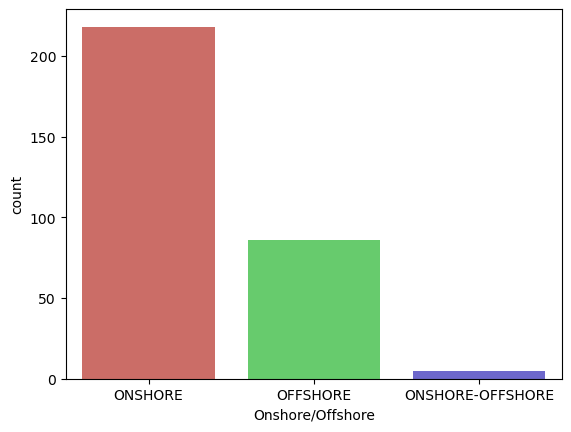

In [96]:

sns.countplot(x=target_col, data=train, palette='hls', hue=target_col, legend=False)
plt.show()

In [97]:
train[target_col].value_counts()

Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

# train_test_split

In [98]:
# Закодируем целевую переменную
# Создание и применение LabelEncoder
encoder = LabelEncoder()
train[target_col] = encoder.fit_transform(train[target_col])

# Создание словаря соответствия
label_mapping = {class_name: index for index, class_name in enumerate(encoder.classes_)}

print(label_mapping)

{'OFFSHORE': 0, 'ONSHORE': 1, 'ONSHORE-OFFSHORE': 2}


In [99]:
train[target_col].value_counts()

Onshore/Offshore
1    218
0     86
2      5
Name: count, dtype: int64

In [100]:
# Удаляем целевую переменную из признаков
X = train.copy().drop(columns=[target_col])
y = train[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y,
                                                   )

print(f'All training set shape: {X.shape}, {y.shape}')
print(f'Train shape: {X_train.shape}, {y_train.shape}')
print(f'Test shape: {X_test.shape}, {y_test.shape}')

All training set shape: (309, 142), (309,)
Train shape: (247, 142), (247,)
Test shape: (62, 142), (62,)


In [101]:
y_train.value_counts()

Onshore/Offshore
1    174
0     69
2      4
Name: count, dtype: int64

In [102]:
y_test.value_counts()

Onshore/Offshore
1    44
0    17
2     1
Name: count, dtype: int64

In [103]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 247 entries, 88 to 20
Columns: 142 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136)
memory usage: 275.9 KB


In [104]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Columns: 142 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136)
memory usage: 342.9 KB


# Балансировка !(код этой главы для сабмита не нужен)

## Undersampling

### Случайное удаление (random undesampling)


In [105]:
y_train.value_counts()

Onshore/Offshore
1    174
0     69
2      4
Name: count, dtype: int64

In [106]:
# Объединяем X_train и y_train в один DataFrame
train_df = pd.concat([X_train, y_train], axis='columns')

In [107]:
train_df

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
88,9.6835,-63.4529,12750,15.0,0,0,1,7.378384,6.746412,6.175867,...,0,0,0,0,0,0,0,1,0,1
97,39.4700,52.7300,10100,18.0,0,0,1,9.012011,5.564520,4.615121,...,0,0,0,0,0,0,0,1,0,0
71,52.2830,-113.5543,4921,13.2,0,0,1,4.753590,2.397895,5.252273,...,0,0,0,0,0,0,0,0,0,1
67,65.0789,7.4898,6480,27.5,0,0,0,6.131226,5.942799,8.635154,...,0,0,0,1,0,0,0,0,0,0
13,54.4995,-115.4904,8540,9.0,0,0,1,5.442418,4.110874,3.828641,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,56.4125,2.0286,7044,13.0,0,0,0,3.433987,3.433987,3.988984,...,0,0,0,1,0,0,0,0,0,0
53,-5.3099,11.9154,3065,24.0,1,0,0,6.111467,5.017280,6.216606,...,0,0,1,0,0,0,0,0,0,0
115,37.0789,-109.2333,5575,14.0,0,0,1,4.394449,3.850148,2.772589,...,1,0,0,0,0,0,0,0,0,1
134,39.5800,53.1300,1800,19.0,0,0,1,8.922792,5.252273,3.433987,...,0,0,0,0,0,0,0,1,0,2


In [108]:
train_df[target_col].value_counts()

Onshore/Offshore
1    174
0     69
2      4
Name: count, dtype: int64

In [109]:
# Количество объектов для каждого класса (на уровне миноритарного класса)
K = train_df[train_df[target_col] == 2].shape[0]

In [110]:
K

4

In [111]:
# Сэмплируем K объектов для классов 0 и 1
df0 = train_df[train_df[target_col] == 0].sample(K, random_state=42)
df1 = train_df[train_df[target_col] == 1].sample(K, random_state=42)

# Берем все объекты класса 2 (миноритарный класс)
df2 = train_df[train_df[target_col] == 2]

# Соединяем все вместе
df_rand_undersaml = pd.concat([df0, df2, df1])

# Разделяем обратно на X_train и y_train
X_train_rand_undersaml = df_rand_undersaml.drop(columns=[target_col])
y_train_rand_undersaml = df_rand_undersaml[target_col]

# Проверка баланса классов
print(y_train_rand_undersaml.value_counts())

Onshore/Offshore
0    4
2    4
1    4
Name: count, dtype: int64


### TomekLinks

Tomek Links идентифицирует пары близких соседей, в которых один пример принадлежит классу меньшинства, а другой - классу большинства. Такие пары соседей называются Tomek Links. После их идентификации удаляется пример из класса большинства, что помогает уменьшить дисбаланс данных.

Процесс начинается с предварительной подготовки данных, должны быть размеченные данные с несбалансированными классами.

Для каждого примера данных мы вычисляем расстояния до всех остальных примеров. Затем для каждого примера из класса меньшинства мы ищем его ближайшего соседа из класса большинства и наоборот. Если расстояние между этими двумя примерами минимальное, они образуют Tomek Link.

После того как все Tomek Links были идентифицированы, мы удаляем примеры, которые находятся на концах этих связей из класса большинства. Это может быть сделано путем создания нового набора данных без этих точек.

In [112]:
# Применяем TomekLinks для очистки границ
tl = TomekLinks()

features_res, labels_res = tl.fit_resample(X_train, y_train)

features_res

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_FORELAND,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH
0,9.6835,-63.4529,12750,15.0,0,0,1,7.378384,6.746412,6.175867,...,0,0,0,0,0,0,0,0,1,0
1,39.4700,52.7300,10100,18.0,0,0,1,9.012011,5.564520,4.615121,...,0,0,0,0,0,0,0,0,1,0
2,52.2830,-113.5543,4921,13.2,0,0,1,4.753590,2.397895,5.252273,...,1,0,0,0,0,0,0,0,0,0
3,65.0789,7.4898,6480,27.5,0,0,0,6.131226,5.942799,8.635154,...,0,0,0,0,1,0,0,0,0,0
4,54.4995,-115.4904,8540,9.0,0,0,1,5.442418,4.110874,3.828641,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,37.0386,-101.0039,1700,14.0,0,0,1,5.484797,3.828641,1.791759,...,1,0,0,0,0,0,0,0,0,0
208,56.4125,2.0286,7044,13.0,0,0,0,3.433987,3.433987,3.988984,...,0,0,0,0,1,0,0,0,0,0
209,-5.3099,11.9154,3065,24.0,1,0,0,6.111467,5.017280,6.216606,...,0,0,0,1,0,0,0,0,0,0
210,37.0789,-109.2333,5575,14.0,0,0,1,4.394449,3.850148,2.772589,...,0,1,0,0,0,0,0,0,0,0


In [113]:
labels_res.value_counts()

Onshore/Offshore
1    155
0     53
2      4
Name: count, dtype: int64

In [114]:
# А теперь используем RandomUnderSampler для точной балансировки
K = 4

rus = RandomUnderSampler(sampling_strategy={0: K, 1: K, 2: K}, random_state=42)

balanced_Tomek, labels_resampled = rus.fit_resample(features_res, labels_res)
balanced_Tomek = pd.concat([balanced_Tomek, labels_resampled], axis='columns')

# Проверяем баланс классов
balanced_Tomek[target_col].value_counts()

Onshore/Offshore
0    4
1    4
2    4
Name: count, dtype: int64

### NearMiss (ближайшие соседи)

Выбирает объекты из мажоритарного класса, которые ближе всего к миноритарным классам. Есть три стратегии!

- `NearMiss-1`: оставляет объекты, ближайшие к $k$ соседям из меньшинства
- `NearMiss-2`: оставляет объекты, ближайшие к среднему расстоянию
- `NearMiss-3`: оставляет объекты, у которых наиболее близкие соседи из меньшинства

In [115]:
y_train.value_counts()

Onshore/Offshore
1    174
0     69
2      4
Name: count, dtype: int64

In [116]:

nm = NearMiss(version=1)
df_NearMiss, y_res = nm.fit_resample(X_train, y_train)

df_NearMiss = pd.concat([df_NearMiss, y_res], axis='columns')

df_NearMiss[target_col].value_counts()

Onshore/Offshore
0    4
1    4
2    4
Name: count, dtype: int64

## Oversampling

### RandomOverSampler (случайная генерация объектов)

Этот метод просто дублирует случайные объекты из миноритарных классов до нужного количества. Самый простой способ увеличить данные.

In [117]:
# Создаем экземпляр RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Применяем oversampling к данным
df_rand_over, y_res = ros.fit_resample(X_train, y_train)
df_rand_over = pd.concat([df_rand_over, y_res], axis='columns')

# Проверка нового распределения классов
df_rand_over[target_col].value_counts()

Onshore/Offshore
1    174
0    174
2    174
Name: count, dtype: int64

In [118]:
y_train.value_counts()

Onshore/Offshore
1    174
0     69
2      4
Name: count, dtype: int64

### SMOTE (Synthetic Minority Over-sampling Technique)

In [119]:
print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (309, 142)
Target distribution:
Onshore/Offshore
1    218
0     86
2      5
Name: count, dtype: int64


In [120]:
# Приводим весь датафрейм к float, чтобы избежать конфликта при интерполяции
X_train_float64 = X_train.astype('float64')

In [121]:
# Применение SMOTE к тренировочным данным
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train_float64, y_train)

# Собираем всё обратно в DataFrame, если нужно
balanced_df_SMOTE = pd.DataFrame(X_train_res, columns=X.columns)
balanced_df_SMOTE[target_col] = y_train_res

balanced_df_SMOTE[target_col].value_counts()

Onshore/Offshore
1    174
0    174
2    174
Name: count, dtype: int64

### ADASYN (Adaptive Synthetic Sampling)


Это улучшенная версия SMOTE, но с умным трюком:

Она генерирует больше синтетических данных для сложных случаев — объектов, которые сложнее классифицировать.

In [122]:
# Создаем экземпляр ADASYN from imblearn.over_sampling
adasyn = ADASYN(random_state=42, n_neighbors=3)

# Применяем ADASYN
X_train_ADASYN, y_train_ADASYN = adasyn.fit_resample(X_train_float64, y_train)

# Собираем всё обратно в DataFrame, если нужно
balanced_df_ADASYN = pd.DataFrame(X_train_ADASYN, columns=X.columns)
balanced_df_ADASYN[target_col] = y_train_ADASYN

balanced_df_ADASYN[target_col].value_counts()


Onshore/Offshore
0    188
1    174
2    172
Name: count, dtype: int64

# Обучение и тестирование моделей

## Дерево решений

In [123]:
# Функция для обучения и оценки модели
def train_and_evaluate(
    X_train, y_train, X_test, y_test, 
    strategy_name, 
    print_res=True, 
    model_type=None, # DecisionTreeClassifier with default parameters
    KNN_max=2,
    max_depth=None,
    min_samples_leaf=2,
):

    # Создаем и обучаем модель
    model_name = model_type or 'DCT'

    if model_type == 'KNN':
        model = KNeighborsClassifier(n_neighbors=KNN_max)
        model_name += '-' + str(KNN_max)
    elif model_type == 'DTC_custom':
        model = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
        model_name += '_d-' + str(max_depth) + '_l-' + str(min_samples_leaf)
    else:
        model = DecisionTreeClassifier(random_state=42)
        
    model.fit(X_train, y_train)

    # Делаем предсказания на тестовых данных
    y_pred = model.predict(X_test)

    # Выводим результаты
    if print_res:
        print(f"Результаты для стратегии: {strategy_name}")
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        # {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’}
        print(f"f1_score macro: {f1_score(y_test, y_pred, average = 'macro', zero_division=0):.4f}")
        print(f"f1_score_weighted: {f1_score(y_test, y_pred, average = 'weighted', zero_division=0):.4f}")
    
        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred, zero_division=0))
        print("="*60)

    res = {'model_name': model_name,
           # 'model': model,
           'strategy_name': strategy_name,
           'Accuracy': accuracy_score(y_test, y_pred),
           "f1_score_macro": f1_score(y_test, y_pred, average = 'macro', zero_division=0),
           "f1_score_weighted": f1_score(y_test, y_pred, average = 'weighted', zero_division=0),
          }

    return res

In [124]:
# Словарь с датасетами
datasets = {
    'Исходная выбока': (
        X_train, 
        y_train,
    ),
    "Random Undersampling": (
        df_rand_undersaml.drop(columns=[target_col]), 
        df_rand_undersaml[target_col],
    ),
    "Tomek Links + Random Undersampling": (
        balanced_Tomek.drop(columns=[target_col]), 
        balanced_Tomek[target_col],
    ),
    "NearMiss": (
        df_NearMiss.drop(columns=[target_col]), 
        df_NearMiss[target_col],
    ),
    "Random Oversampling": (
        df_rand_over.drop(columns=[target_col]), 
        df_rand_over[target_col],
    ),
    "SMOTE": (
        balanced_df_SMOTE.drop(columns=[target_col]),
        balanced_df_SMOTE[target_col],
    ),
    "ADASYN": (
        balanced_df_ADASYN.drop(columns=[target_col]),
        balanced_df_ADASYN[target_col],
    ),
}

In [125]:
results = []
# переберем параметры для KNN
for i in range(2,12): # max 12 else error
    for strategy, (X_balanced, y_balanced) in datasets.items():
        results.append(
            train_and_evaluate(
                X_balanced, y_balanced, X_test, y_test, 
                strategy, print_res=False, 
                model_type='KNN', KNN_max=i
            )
        )

# добавим DecisionTreeClassifier
# Задаем списки значений, которые хотим проверить
max_depth_values = [2, 3, 4, 5, 6, 7, 10, None]
min_samples_leaf_values = [1, 2, 3, 4, 5, 7, 10, 15, 20]

# Вложенные циклы для перебора комбинаций
for depth in max_depth_values:
    for leaf in min_samples_leaf_values:
        for strategy, (X_balanced, y_balanced) in datasets.items():
            results.append( train_and_evaluate(
                X_balanced, y_balanced, X_test, y_test, strategy, print_res=False,
                model_type='DTC_custom',
                max_depth=depth,
                min_samples_leaf=leaf,
            ))

for strategy, (X_balanced, y_balanced) in datasets.items():
    results.append(train_and_evaluate(X_balanced, y_balanced, X_test, y_test, strategy, print_res=False))

scores = pd.DataFrame(results)
scores.T

,0,1,2,3,4,5,6,7,8,9,...,571,572,573,574,575,576,577,578,579,580
model_name,KNN-2,KNN-2,KNN-2,KNN-2,KNN-2,KNN-2,KNN-2,KNN-3,KNN-3,KNN-3,...,DTC_custom_d-None_l-20,DTC_custom_d-None_l-20,DTC_custom_d-None_l-20,DCT,DCT,DCT,DCT,DCT,DCT,DCT
strategy_name,Исходная выбока,Random Undersampling,Tomek Links + Random Undersampling,NearMiss,Random Oversampling,SMOTE,ADASYN,Исходная выбока,Random Undersampling,Tomek Links + Random Undersampling,...,Random Oversampling,SMOTE,ADASYN,Исходная выбока,Random Undersampling,Tomek Links + Random Undersampling,NearMiss,Random Oversampling,SMOTE,ADASYN
Accuracy,0.580645,0.290323,0.451613,0.080645,0.564516,0.564516,0.5,0.596774,0.274194,0.451613,...,0.709677,0.758065,0.790323,0.790323,0.467742,0.419355,0.354839,0.806452,0.822581,0.854839
f1_score_macro,0.375,0.203106,0.38535,0.091005,0.368994,0.456703,0.463399,0.348659,0.225955,0.38535,...,0.493819,0.479566,0.514458,0.503038,0.330248,0.35,0.267109,0.531328,0.542448,0.550649
f1_score_weighted,0.59879,0.263846,0.470778,0.094214,0.586003,0.600472,0.521316,0.597145,0.200274,0.470778,...,0.747531,0.754882,0.790459,0.788508,0.5538,0.458871,0.419883,0.810332,0.825335,0.848848


In [126]:
scores.describe()

,Accuracy,f1_score_macro,f1_score_weighted
count,581.000000,581.000000,581.000000
mean,0.579757,0.383185,0.567977
std,0.219677,0.142454,0.255915
min,0.080645,0.090869,0.090144
25%,0.354839,0.267109,0.419883
50%,0.596774,0.414293,0.608153
75%,0.790323,0.509756,0.788508
max,0.870968,0.565773,0.865839


In [127]:
metrics = ['Accuracy', 'f1_score_macro', 'f1_score_weighted']
for metric in metrics:
    display( scores[scores[metric] == scores[metric].max()] )

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
419,DTC_custom_d-7_l-5,ADASYN,0.870968,0.565773,0.865839
454,DTC_custom_d-10_l-1,ADASYN,0.870968,0.565773,0.865839
482,DTC_custom_d-10_l-5,ADASYN,0.870968,0.565773,0.865839
524,DTC_custom_d-None_l-2,ADASYN,0.870968,0.565773,0.865839
545,DTC_custom_d-None_l-5,ADASYN,0.870968,0.565773,0.865839


,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
419,DTC_custom_d-7_l-5,ADASYN,0.870968,0.565773,0.865839
454,DTC_custom_d-10_l-1,ADASYN,0.870968,0.565773,0.865839
482,DTC_custom_d-10_l-5,ADASYN,0.870968,0.565773,0.865839
524,DTC_custom_d-None_l-2,ADASYN,0.870968,0.565773,0.865839
545,DTC_custom_d-None_l-5,ADASYN,0.870968,0.565773,0.865839


,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
419,DTC_custom_d-7_l-5,ADASYN,0.870968,0.565773,0.865839
454,DTC_custom_d-10_l-1,ADASYN,0.870968,0.565773,0.865839
482,DTC_custom_d-10_l-5,ADASYN,0.870968,0.565773,0.865839
524,DTC_custom_d-None_l-2,ADASYN,0.870968,0.565773,0.865839
545,DTC_custom_d-None_l-5,ADASYN,0.870968,0.565773,0.865839


Лучший результат показало Дерево решений с балансировкой ADASYN, при k=3 (другие k подобрать не получится, так как у нас в выборке только 4 объекта миноритарного класса, а алгоритм требует, чтобы k было меньше или равно).

При этом, несколько параметров Дерева решений дало лучший результат. Выберем тот, у кого глубина меньше, а экземпляров в листе больше, так как эти параметры менее склонны к переобучению.

In [128]:
best_max_depth = 7
best_min_samples_leaf = 5

## Случайный лес

Ключевым недостатком деревьев решений является их «склонность» к переобучению, а также тот факт, что даже при небольшом изменении обучающей выборки дерево может значительно измениться. Однако объединение деревьев в ансамбли или композиции на практике дает очень хорошие результаты.

В задачах классификации рекомендуется брать $m = \sqrt{d}$, где $d$ - общее число признаков, и строить дерево до тех пор, пока в каждом листе не останется по одному объекту, а в задаче регрессии принимать $m = d/3$ и строить дерево, пока в листьях не останется по пять объектов.

In [129]:
(X_train.shape[1])**(1/2)

11.916375287812984

In [130]:
scores[scores['strategy_name'] == 'Исходная выбока'].sort_values(
    by=['f1_score_weighted', 'f1_score_macro', 'Accuracy'],
    ascending=False,
).head(10)

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
294,DTC_custom_d-5_l-7,Исходная выбока,0.854839,0.550366,0.845135
357,DTC_custom_d-6_l-7,Исходная выбока,0.854839,0.550366,0.845135
420,DTC_custom_d-7_l-7,Исходная выбока,0.854839,0.550366,0.845135
483,DTC_custom_d-10_l-7,Исходная выбока,0.854839,0.550366,0.845135
546,DTC_custom_d-None_l-7,Исходная выбока,0.854839,0.550366,0.845135
301,DTC_custom_d-5_l-10,Исходная выбока,0.838710,0.534920,0.831461
364,DTC_custom_d-6_l-10,Исходная выбока,0.838710,0.534920,0.831461
427,DTC_custom_d-7_l-10,Исходная выбока,0.838710,0.534920,0.831461
490,DTC_custom_d-10_l-10,Исходная выбока,0.838710,0.534920,0.831461
553,DTC_custom_d-None_l-10,Исходная выбока,0.838710,0.534920,0.831461


In [131]:
# Создание и обучение модели
clf = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=42,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
    #max_depth=5,
    #min_samples_leaf=7,
)
clf.fit(X_train, y_train)

# Предсказание и оценка качества модели
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1_score_macro = f1_score(y_test, y_pred, average = 'macro', zero_division=0)
f1_score_weighted = f1_score(y_test, y_pred, average = 'weighted', zero_division=0)


print(f'Точность, f1_macro, f1_weighted: {accuracy:.4f}, {f1_score_macro:.4f}, {f1_score_weighted:.4f}')

Точность, f1_macro, f1_weighted: 0.9032, 0.5912, 0.8934


Пока лучший результат на тесте (.90 .59 .89).

Возьмём сбалансированные классы

In [132]:
scores[scores['strategy_name'] == 'ADASYN'].sort_values(
    by=['f1_score_weighted', 'f1_score_macro', 'Accuracy'],
    ascending=False,
).head(10)

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
419,DTC_custom_d-7_l-5,ADASYN,0.870968,0.565773,0.865839
454,DTC_custom_d-10_l-1,ADASYN,0.870968,0.565773,0.865839
482,DTC_custom_d-10_l-5,ADASYN,0.870968,0.565773,0.865839
524,DTC_custom_d-None_l-2,ADASYN,0.870968,0.565773,0.865839
545,DTC_custom_d-None_l-5,ADASYN,0.870968,0.565773,0.865839
517,DTC_custom_d-None_l-1,ADASYN,0.854839,0.550649,0.848848
580,DCT,ADASYN,0.854839,0.550649,0.848848
342,DTC_custom_d-6_l-3,ADASYN,0.838710,0.543653,0.836572
349,DTC_custom_d-6_l-4,ADASYN,0.838710,0.543653,0.836572
356,DTC_custom_d-6_l-5,ADASYN,0.838710,0.543653,0.836572


In [133]:
# Создание и обучение модели
clf = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=42,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
    #max_depth=5,
    #min_samples_leaf=7,
)
clf.fit(X_train_ADASYN, y_train_ADASYN)

# Предсказание и оценка качества модели
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1_score_macro = f1_score(y_test, y_pred, average = 'macro', zero_division=0)
f1_score_weighted = f1_score(y_test, y_pred, average = 'weighted', zero_division=0)


print(f'Точность, f1_macro, f1_weighted: {accuracy:.4f}, {f1_score_macro:.4f}, {f1_score_weighted:.4f}')

Точность, f1_macro, f1_weighted: 0.8710, 0.5697, 0.8645


In [134]:
# Создание и обучение модели
clf = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=42,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
    max_depth=7,
    min_samples_leaf=5,
)
clf.fit(X_train_ADASYN, y_train_ADASYN)

# Предсказание и оценка качества модели
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1_score_macro = f1_score(y_test, y_pred, average = 'macro', zero_division=0)
f1_score_weighted = f1_score(y_test, y_pred, average = 'weighted', zero_division=0)


print(f'Точность, f1_macro, f1_weighted: {accuracy:.4f}, {f1_score_macro:.4f}, {f1_score_weighted:.4f}')

Точность, f1_macro, f1_weighted: 0.8226, 0.5392, 0.8213


## CatBoostig

In [135]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

# Если у вас есть категориальные колонки, запишите их индексы или имена
cat_features = cat_cols # пример из вашего описания


In [139]:
cat_cols

['Country',
 'Region',
 'Hydrocarbon type',
 'Reservoir status',
 'Era',
 'Main_Tectonic',
 'Lithology_grouped',
 'Basin_grouped',
 'Main_Structural']

In [140]:
X.columns

Index(['Latitude', 'Longitude', 'Depth', 'Porosity', 'Has_Gravity',
       'Has_Evaporite', 'Has_Compression', 'log_Thickness (gross average ft)',
       'log_Thickness (net pay average ft)', 'log_Permeability',
       ...
       'Main_Structural_FORELAND', 'Main_Structural_INTRACRATONIC',
       'Main_Structural_INVERSION', 'Main_Structural_PASSIVE MARGIN',
       'Main_Structural_RIFT', 'Main_Structural_SALT',
       'Main_Structural_SUB-SALT', 'Main_Structural_SUB-THRUST',
       'Main_Structural_THRUST', 'Main_Structural_WRENCH'],
      dtype='str', length=142)

In [138]:
model = CatBoostClassifier(
    iterations=1000,
    early_stopping_rounds=50, # остановится, если качество перестанет расти (защита от переобучения)
    auto_class_weights='Balanced', # магическая кнопка для дисбаланса
    loss_function='MultiClass',    # так как у вас 3 класса
    eval_metric='TotalF1',         # следим за F1-мерой
    task_type="CPU"                # или "GPU", если данных много
)

model.fit(
    X, y,
    cat_features=cat_cols,
    #eval_set=(X_val, y_val), # валидационная выборка для контроля переобучения
    verbose=100
)


ValueError: 'Country' is not in list

# вывести confusion matrix

# Финальный сабмит

In [ ]:
display(train.shape)
display(test.shape)
train = train.dropna()
display(train.shape)

In [ ]:
display(X.shape)
display(y.shape)

In [ ]:
# заполним числовые NaN медианными значениями (pandas расчитает это самостоятельно)
# оставшиеся строковые, как Unknown
test = test.fillna(test.median())
test = test.fillna('Unknown')

## Random Forest

In [ ]:
# Создание и обучение модели
clf_best = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=42,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
    #max_depth=5,
    #min_samples_leaf=7,
)
clf_best.fit(X, y)

# Предсказание и оценка качества модели
y_pred_clf = clf_best.predict(test)
y_pred_clf

In [ ]:
submition_EDA_FE_dummies_Orig_RF_100_log2_86432 = np.array(
      [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [ ]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_clf == submition_EDA_FE_dummies_Orig_RF_100_log2_86432)

In [ ]:
# выгрузка в файл для сабмита
ans_clf = pd.DataFrame(y_pred_clf, columns=['Onshore/Offshore'])
ans_clf.reset_index(inplace=True)
ans_clf.to_csv('./classification-of-oil-and-gas/submition_EDA_FE_dummies_Orig_RF-100-log2.csv', index=False)

## baseline Decision Tree

In [ ]:
# создадим модель
baseline_tree = DecisionTreeClassifier(random_state=42)

# обучение модели
baseline_tree.fit(X, y)

# предсказание ответов для тестовой выборки
y_pred_baseline_tree = baseline_tree.predict(test)
y_pred_baseline_tree

In [ ]:
submition_EDA_FE_wo_BN_dummies_Orig_DTC_baseline_88652 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [ ]:
submition_EDA_FE_dummies_Orig_DTC_baseline_88652 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [ ]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_baseline_tree == submition_EDA_FE_wo_BN_dummies_Orig_DTC_baseline_88652)

In [ ]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_baseline_tree == submition_EDA_FE_dummies_Orig_DTC_baseline_88652)

In [ ]:
# выгрузка в файл для сабмита
ans_clf = pd.DataFrame(y_pred_baseline_tree, columns=['Onshore/Offshore'])
ans_clf.reset_index(inplace=True)
ans_clf.to_csv('./classification-of-oil-and-gas/submition_EDA_FE_dummies_Orig_DCT_baseline.csv', index=False)

## предыдущие

In [ ]:

# Применяем ADASYN
X_all_ADASYN, y_all_ADASYN = adasyn.fit_resample(X, y)

# Создадим модель дерева решений
tree = DecisionTreeClassifier(
    random_state=42, 
    max_depth=best_max_depth, 
    min_samples_leaf=best_min_samples_leaf,
)

# обучение модели
tree.fit(X_all_ADASYN, y_all_ADASYN)

# предсказание ответов для тестовой выборки
y_pred_tree = tree.predict(test)

y_pred_tree

In [ ]:
submition_ADASYN_DCT_d7_l5_85396 = np.array(
      [1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 2,
       1, 1, 1, 0, 0, 1, 0, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 2, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1])

In [ ]:
# проверка, равены текущее предсказание последнему сабмиту
all(y_pred_tree == submition_ADASYN_DCT_d7_l5_85396)

In [ ]:
# выгрузка в файл для сабмита
ans_df = pd.DataFrame(y_pred_tree, columns=['Onshore/Offshore'])
ans_df.reset_index(inplace=True)
ans_df.to_csv('./classification-of-oil-and-gas/submition_EDA_FE_dummies_ADASYN_DTC-d7-l5.csv', index=False)

In [ ]:
submition_ADASYN_DCT_d7_l5_83786 = np.array(
      [0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 2, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1])

In [ ]:
# проверка, равены текущее предсказание последнему сабмиту
all(y_pred_tree == submition_ADASYN_DCT_d7_l5_83786)

In [ ]:
submition_ADASYN_DCT_86676 = np.array(
      [1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [ ]:
# проверка, равены текущее предсказание последнему сабмиту
all(y_pred_tree == submition_ADASYN_DCT_86676)

In [ ]:
submition_baseline_DCT_fillna_map_group_log_88652 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [ ]:
# проверка, равены текущее предсказание последнему сабмиту
all(y_pred_tree == submition_baseline_DCT_fillna_map_group_log_88652)

In [ ]:
X_train.shape, y_train.shape